# Exercise 2 -  Time evolution of phytoplankton & nutrient concentrations

**Name:** Tristan Mitchell  
**Student Number:** MTCTRI001

### AI Declaration
I asked Claude.ai for help with writing certain code sections for questions 2 and 3, which I then edited and improved. 


In [1]:
# Import needed packages:
import numpy as np
import matplotlib.pyplot as plt

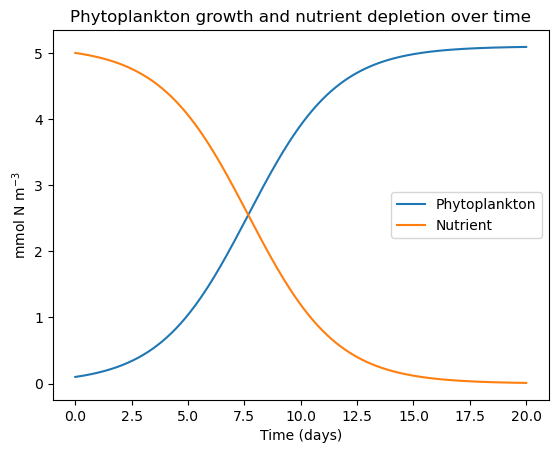

In [2]:
# Exercise Questions to answer in code 
"""
Answer the following questions (adding plots where needed)
1. Why are the curves identical in shape?
2. What happens when you change the value of the uptake parameter? Think about it as the percentage of food consumed per day.
3. What happens if the initial biomass of phytoplankton is close to the amount of resource available? How does the shape of the curve change?
"""

# define constants
k_prime = 0.1 # (d^-1) uptake parameter (instantaneous growth rate)
P_0 = 0.1 # mmol N m^-3 conc of phytoplankton at t = 0
N_0 = 5.0 # mmol N m^-3 conc of nutrient at t = 0

# Generate time values from 0 to 20 days, with 500 points 
time = np.linspace(0, 20, 480) # one point per hour (20 × 24 = 480 points)

# Define the function for phytoplankton (consumer) growth.
def phytoplankton(time):
    return (P_0*(P_0+N_0)/(P_0+N_0*np.exp(-k_prime*(P_0+N_0)*time)))

phytoplankton_values = phytoplankton(time) # calc the pop size at all times 

# Define the function for nutrient depletion.
def nutrient(time):
    return (P_0+N_0-phytoplankton_values)

nutrient_values = nutrient(time) # calc the nutrient pool at all times 

# Plotting the figure 
plt.plot(time, phytoplankton_values, label="Phytoplankton") # phytoplankton growth
plt.plot(time, nutrient_values, label="Nutrient") # nutrient depletion
plt.xlabel("Time (days)")
plt.ylabel("mmol N m$^{-3}$")
plt.title("Phytoplankton growth and nutrient depletion over time")
plt.legend()

# Showing the figure
plt.show()

## Question1 
The curves have the same shape because mass is conserved. As nutrient levels drop, phytoplankton levels rise by an equivalent amount. In other words, the phytoplankton curve mirrors the nutrient curve in the opposite direction. We know this from the formula (P + N = P0 + N0).

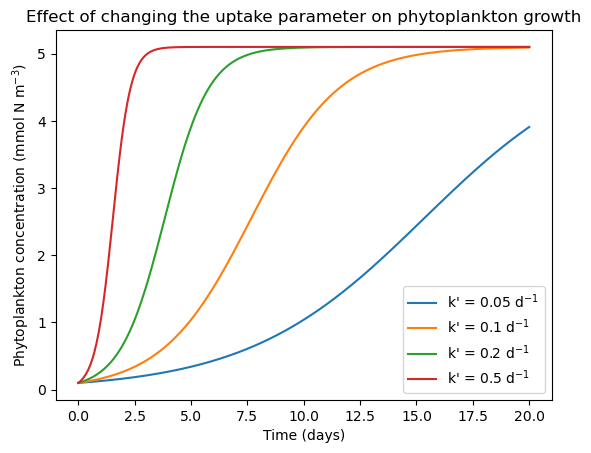

In [10]:
# Question 2 code
# Generate time values from 0 to 20 days, with 480 points
time = np.linspace(0, 20, 480)

# constants 
P_0 = 0.1 # mmol N m^-3 conc of phytoplankton at t = 0
N_0 = 5.0 # mmol N m^-3 conc of nutrient at t = 0

# Changing the value of the uptake parameter
k_prime_values = [0.05, 0.1, 0.2, 0.5] # The 0.05 didn't reach the carrying capacity because the uptake rate is too slow over the 20-day period

# Plotting the figure 
for k_prime in k_prime_values: 
    phytoplankton_values = (P_0*(P_0+N_0)/(P_0+N_0*np.exp(-k_prime*(P_0+N_0)*time)))
    plt.plot(time, phytoplankton_values, label=f"k' = {k_prime} d$^{{-1}}$")

# Adding labels and legend 
plt.xlabel("Time (days)")
plt.ylabel("Phytoplankton concentration (mmol N m$^{-3}$)")
plt.title("Effects of changing the uptake parameter on phytoplankton growth")
plt.legend()

# Showing the figure
plt.show()

## Question 2
Increasing k’ (the uptake parameter) makes phytoplankton grow faster because nutrients are consumed more quickly. The curve becomes steeper and reaches the carrying capacity sooner. Decreasing k’ has the opposite effect, resulting in slower growth and more time for the phytoplankton concentration to reach the plateau (carrying capacity).

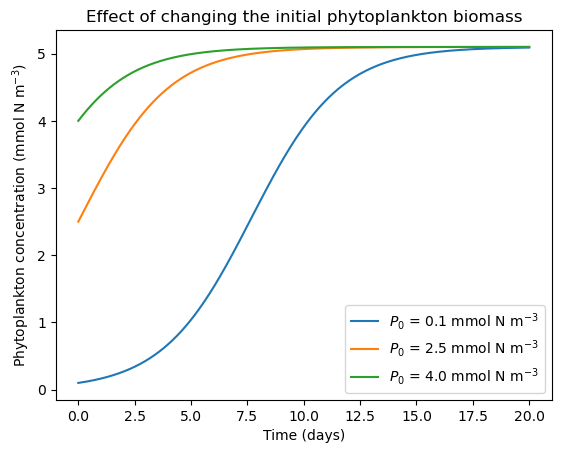

In [14]:
# Question 3
# Generate time values from 0 to 20 days, with 500 points
time = np.linspace(0, 20, 500)

P_0_values = [0.1, 2.5, 4.0] # Changing the initial phytoplankton biomass
k_prime = 0.1 # (d^-1) uptake parameter (instantaneous growth rate)

# conservation of mass (P + N = P0 + N0)
total_nitrogen = 0.1 + 5.0 # total Nitrogen = P_0 + N_0 = 0.1 + 5.0 = 5.1 mmol N m^-3

# Plotting the figure
for P_0 in P_0_values:
    N_0 = total_nitrogen - P_0 # Calc the remaining nutrient concentration
    phytoplankton_values = (P_0*(P_0+N_0)/(P_0+N_0*np.exp(-k_prime*(P_0+N_0)*time)))
    plt.plot(time, phytoplankton_values, label=f"$P_0$ = {P_0} mmol N m$^{{-3}}$")

# Adding in the labels and legend 
plt.xlabel("Time (days)")
plt.ylabel("Phytoplankton concentration (mmol N m$^{-3}$)")
plt.title("Effect of changing the initial phytoplankton biomass")
plt.legend()

# Showing the figure
plt.show()

## Question 3
When the initial phytoplankton biomass is near the resource limit, the population begins closer to the carrying capacity. This results in a shorter lag phase, and the typical S-shaped growth curve is less pronounced. The curve rapidly increases and then plateaus because only a limited amount of further growth can occur before nutrients become depleted.